Використай цей шаблон в роботі з датасетом.    
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.    
Обмежся функціями з наведених бібліотек.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master.    
Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою.    
Тепер сформуй список файлів, які ти будеш завантажувати.    
Для формування послідовності слід використати функцію numpy.arange.    
Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно).    
Повну адресу сформуй через конкатенацію рядків.

In [38]:
json_dir = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/"

years = np.arange(1960, 2001, 10) 

# Список через конкатенацію
file_urls = [json_dir + f"movies-{year}s.json" for year in years]

print(f"Завантажено {len(file_urls)} файлів.")


Завантажено 5 файлів.


2. Тепер послідовність дій наступна.   
Слід пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт.        
Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].     
Залишити лише повні рядки(рядки без пропущених значень).     
Об'єднати інформацію з усіх файлів в єдиний датасет.

In [6]:
all_movies = []
cols_to_drop = ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']

for url in file_urls:
    df_temp = pd.read_json(url)
    
    df_temp = df_temp.drop(columns=cols_to_drop)
    
    df_temp = df_temp.dropna()
    
    all_movies.append(df_temp)

df = pd.concat(all_movies, ignore_index=True)

3. Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Збережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [7]:
print(f"Розмір фінального датасету: {df.shape}")
df.info()

df.to_csv('movies_backup.csv', index=False)

Розмір фінального датасету: (10750, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10750 entries, 0 to 10749
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   10750 non-null  object
 1   year    10750 non-null  int64 
 2   cast    10750 non-null  object
 3   genres  10750 non-null  object
dtypes: int64(1), object(3)
memory usage: 336.1+ KB


4. Для json файлу не варто використовувати метод describe. Файл містить вкладені структури.    
Перевір вміст перших рядочків і використай метод info.

In [8]:
df.head()

,title,year,cast,genres
0,The 3rd Voice,1960,"[Edmond O'Brien, Laraine Day, Julie London]","[Mystery, Crime, Drama, Noir, Thriller]"
1,12 to the Moon,1960,"[Ken Clark, Tom Conway]","[Science Fiction, Independent]"
2,13 Fighting Men,1960,"[Grant Williams, Carole Matthews]","[War, Drama]"
3,13 Ghosts,1960,"[Charles Herbert, Jo Morrow]","[Horror, Supernatural]"
4,The Adventures of Huckleberry Finn,1960,"[Tony Randall, Patty McCormack, Eddie Hodges, ...","[Family, Drama]"


5. Тепер слід попрацювати з жанрами.    
Віднайди топ 10 жанрів за кількістю фільмів.    
Побудуй стовпчикову та кругову діаграму, а також виведи на екран підсумкову таблицю.

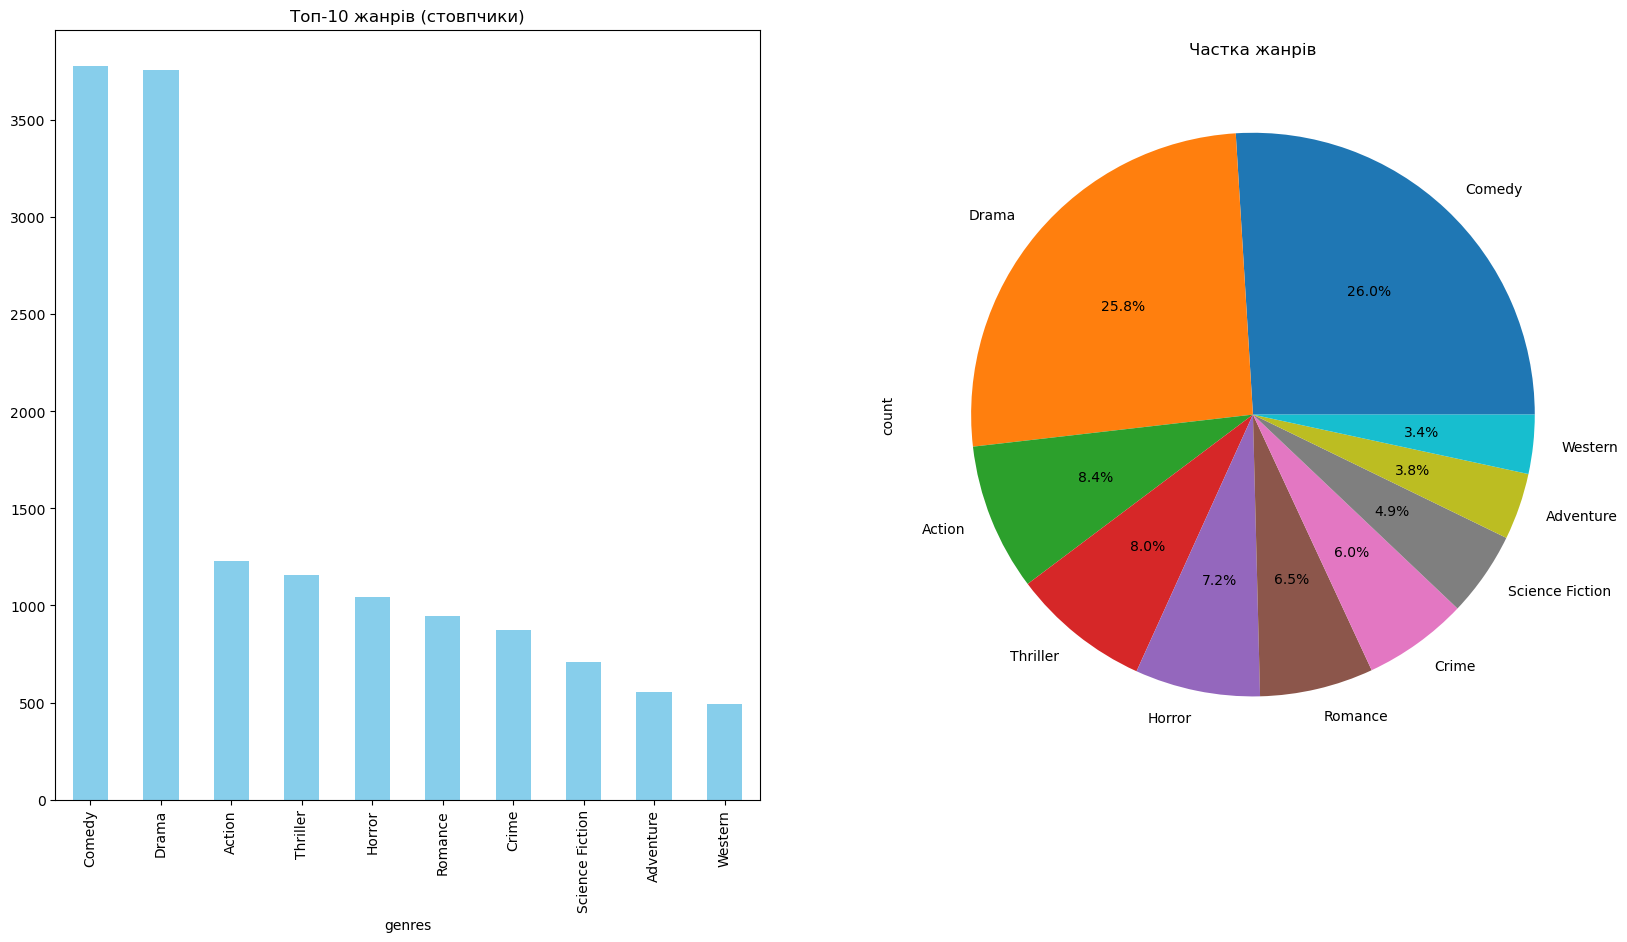

Підсумкова таблиця жанрів:
genres
Comedy             3777
Drama              3758
Action             1228
Thriller           1158
Horror             1044
Romance             948
Crime               873
Science Fiction     708
Adventure           556
Western             492
Name: count, dtype: int64


In [12]:
genres_exploded = df.explode('genres')

top_10_genres = genres_exploded['genres'].value_counts().head(10)

# Візуалізація
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
top_10_genres.plot(kind='bar', ax=ax[0], color='skyblue', title='Топ-10 жанрів (стовпчики)')
top_10_genres.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', title='Частка жанрів')
plt.show()

print("Підсумкова таблиця жанрів:")
print(top_10_genres)

6. Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.     
Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

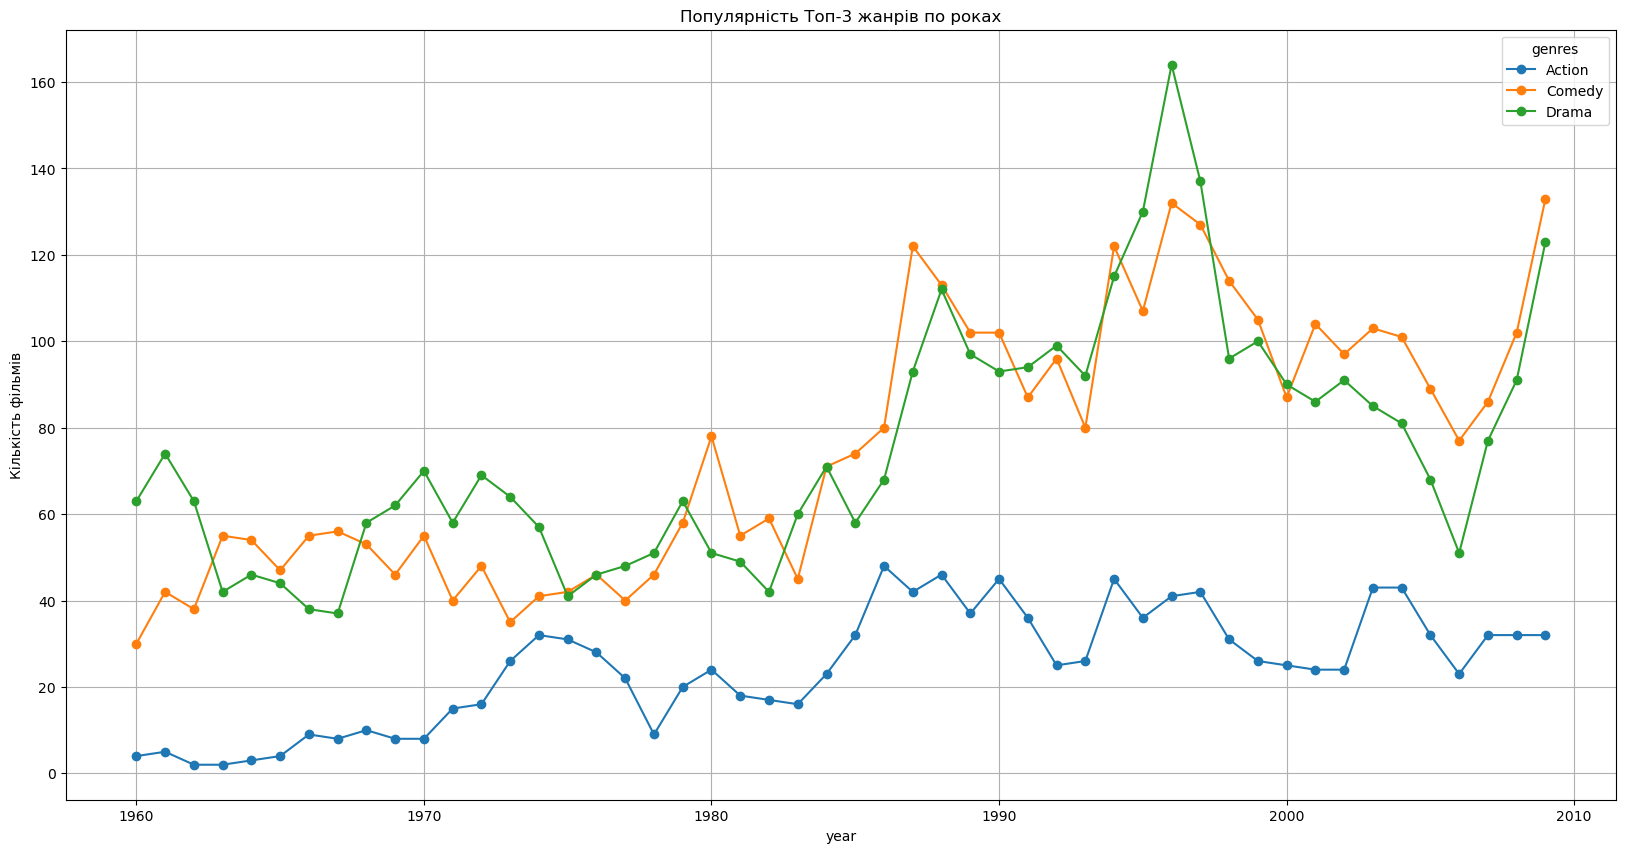

In [15]:
top_3_genres_names = top_10_genres.head(3).index.tolist()

genres_trend = genres_exploded[genres_exploded['genres'].isin(top_3_genres_names)] \
               .groupby(['year', 'genres']).size().unstack(fill_value=0)

# Візуалізація
genres_trend.plot(kind='line', marker='o', figsize=(20, 10), title='Популярність Топ-3 жанрів по роках')
plt.ylabel('Кількість фільмів')
plt.grid(True)
plt.show()

7. Тепер слід попрацювати з акторами.     
Віднайди топ 10 акторів за кількістю фільмів.    
Побудуй стовпчикову або кругову діаграму, а також виведи на екран підсумукову таблицю.

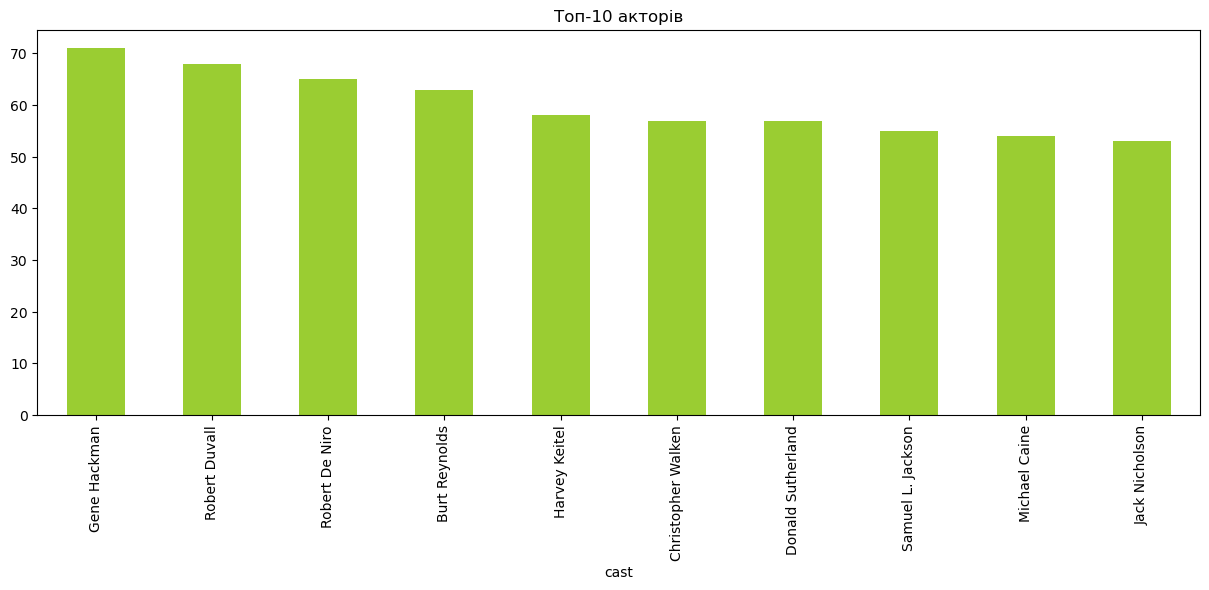

Підсумкова таблиця: Топ-10 акторів
cast
Gene Hackman          71
Robert Duvall         68
Robert De Niro        65
Burt Reynolds         63
Harvey Keitel         58
Christopher Walken    57
Donald Sutherland     57
Samuel L. Jackson     55
Michael Caine         54
Jack Nicholson        53
Name: count, dtype: int64


In [32]:
cast_exploded = df.explode('cast')
top_10_actors = cast_exploded['cast'].value_counts().head(10)

# Візуалізація
top_10_actors.plot(kind='bar', figsize=(15, 5), color='yellowgreen', title='Топ-10 акторів')
plt.show()

print("Підсумкова таблиця: Топ-10 акторів")
print(top_10_actors)

8. Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.
Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

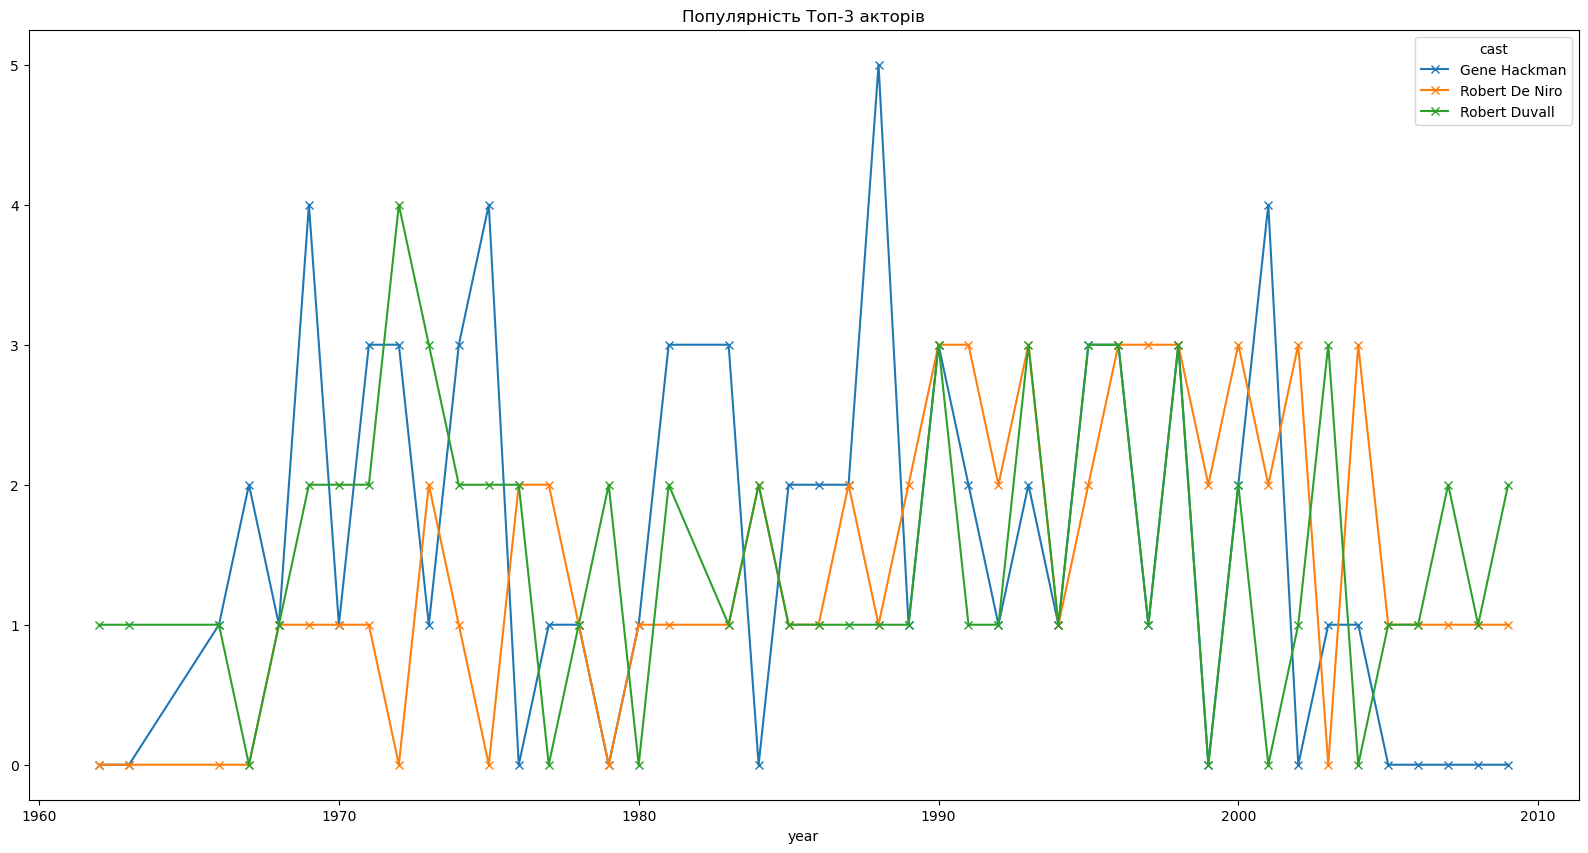

In [33]:
top_3_actors_names = top_10_actors.head(3).index.tolist()
actors_trend = cast_exploded[cast_exploded['cast'].isin(top_3_actors_names)] \
               .groupby(['year', 'cast']).size().unstack(fill_value=0)

# Візуалізація
actors_trend.plot(kind='line', marker='x', figsize=(20, 10), title='Популярність Топ-3 акторів')
plt.show()

***Бонусне завдання***       
Зосередься лише на 10 найпопулярніших акторах.     
 Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, та як часто в фільмі, що не включає топовий жанр.  
 Оціни пропорції для кожного актора у вигляді стовпчикової діаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.

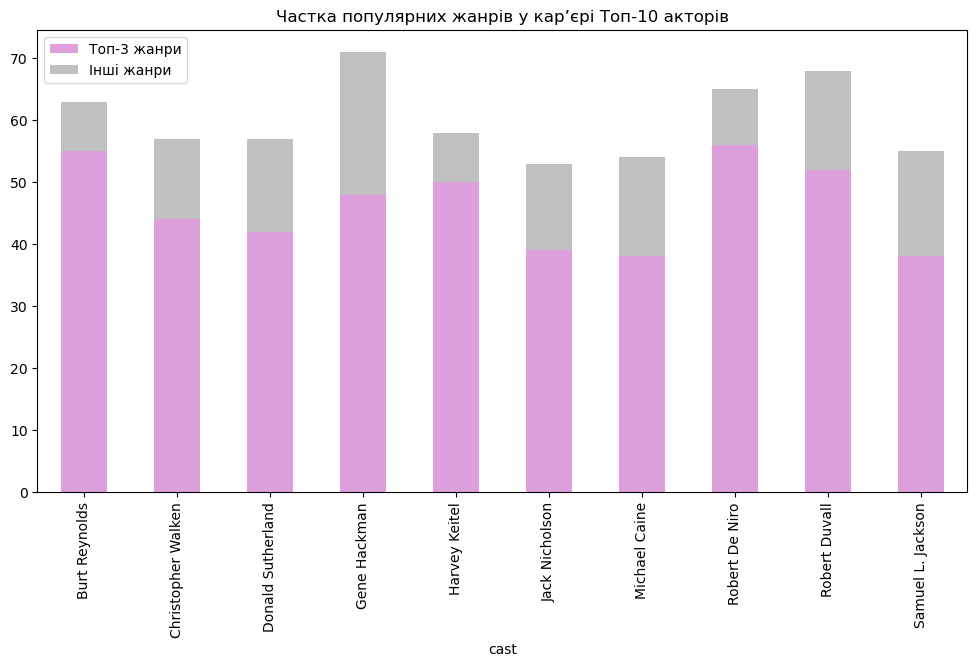

                    Інші жанри  Топ-3 жанри  Всього  % у Топ-жанрах
cast                                                               
Burt Reynolds                8           55      63           87.30
Christopher Walken          13           44      57           77.19
Donald Sutherland           15           42      57           73.68
Gene Hackman                23           48      71           67.61
Harvey Keitel                8           50      58           86.21
Jack Nicholson              14           39      53           73.58
Michael Caine               16           38      54           70.37
Robert De Niro               9           56      65           86.15
Robert Duvall               16           52      68           76.47
Samuel L. Jackson           17           38      55           69.09


In [37]:

top_3_set = set(top_3_genres_names)

# Функція
def is_in_top(genres_list):
    return any(g in top_3_set for g in genres_list)

df['is_top_genre'] = df['genres'].apply(is_in_top)

bonus_data = df.explode('cast')
bonus_data = bonus_data[bonus_data['cast'].isin(top_10_actors.index)]


bonus_tabl = bonus_data.groupby(['cast', 'is_top_genre']).size().unstack(fill_value=0)
bonus_tabl.columns = ['Інші жанри', 'Топ-3 жанри']
bonus_tabl['Всього'] = bonus_tabl.sum(axis=1)
bonus_tabl['% у Топ-жанрах'] = (bonus_tabl['Топ-3 жанри'] / bonus_tabl['Всього'] * 100).round(2)

# Даіграмма
bonus_tabl[['Топ-3 жанри', 'Інші жанри']].plot(kind='bar', stacked=True, figsize=(12, 6), color=['plum', 'silver'])
plt.title('Частка популярних жанрів у кар’єрі Топ-10 акторів')
plt.show()

print(bonus_tabl)